# Financial Fraud Project
## Exploratory Data Analysis

This notebook covers univariate, bivariate, and multivariate analysis to identify patterns associated with fraudulent transactions.

## Project Goal
The goal of this project is to help Caishen Bank detect fraudulent 
transactions in their customer accounts. To do this, I will analyze 
a dataset of bank transactions and build a machine learning model 
that can flag suspicious activity.

## Target Variable
- **`isFraud`** — This column tells us if a transaction was fraudulent. 
1 means fraud, 0 means not fraud.

## Prediction Objective
I want to predict whether a transaction is fraudulent or not based on 
information like the transaction type, the amount of money transferred, 
and the account balances before and after the transaction. Since fraud 
cases are very rare in this dataset, I will use F1-score to measure 
how well my model is performing rather than just accuracy.

## 1.Loading Data

In this section I am importing all the libraries I need to run my analysis 
and loading the dataset into a dataframe so I can start exploring it.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [24]:

df = pd.read_csv('Finanacial dataset project.csv')
df.head()



,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


## Basic Data Overview
Here I am checking the shape of the dataset, the data types, 
any missing values, and getting a general summary of the data 
before I start my analysis.

In [25]:
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (6362620, 11)
Columns: ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']


In [26]:
print("Data Types:")
print(df.dtypes)

Data Types:
step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object


In [27]:
# Missing values
print("Missing values:\n", df.isnull().sum())

Missing values:
 step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


In [28]:
# Duplicate rows
print("\nDuplicate rows:", df.duplicated().sum())


Duplicate rows: 0


In [29]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [30]:
print("Transaction Types:")
print(df['type'].value_counts())

Transaction Types:
type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64


In [31]:
print("Fraud distribution:")
print(df['isFraud'].value_counts())
print("\nFraud rate: {:.4f}%".format(df['isFraud'].mean() * 100))

Fraud distribution:
isFraud
0    6354407
1       8213
Name: count, dtype: int64

Fraud rate: 0.1291%


## 2. Univariate Analysis

Here I am looking at each variable individually to understand 
the distribution of the data and spot any patterns.

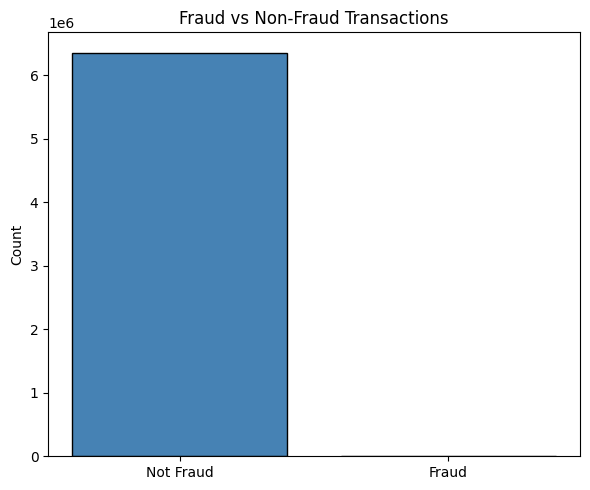

Not Fraud: 99.87%
Fraud:     0.129%
Dataset is highly imbalanced — accuracy alone is a misleading metric.


In [32]:
# --- Class Imbalance ---
fraud_counts = df['isFraud'].value_counts()
fraud_pct = df['isFraud'].value_counts(normalize=True) * 100

plt.figure(figsize=(6, 5))
plt.bar(['Not Fraud', 'Fraud'], fraud_counts.values,
        color=['steelblue', 'tomato'], edgecolor='black')
plt.title('Fraud vs Non-Fraud Transactions')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(f'Not Fraud: {fraud_pct[0]:.2f}%')
print(f'Fraud:     {fraud_pct[1]:.3f}%')
print('Dataset is highly imbalanced — accuracy alone is a misleading metric.')

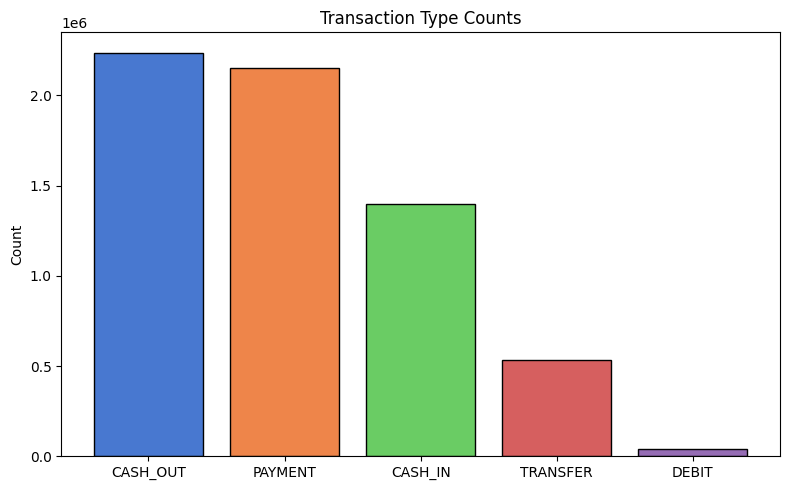

In [33]:
# --- Transaction Type Distribution ---
type_counts = df['type'].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(type_counts.index, type_counts.values,
        color=sns.color_palette('muted', len(type_counts)), edgecolor='black')
plt.title('Transaction Type Counts')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

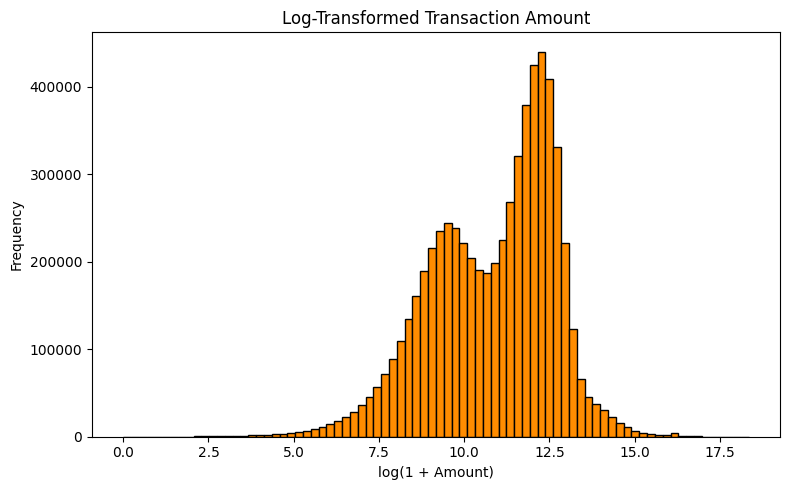

In [34]:
# --- Transaction Amount Distribution ---
plt.figure(figsize=(8, 5))
plt.hist(np.log1p(df['amount']), bins=80, color='darkorange', edgecolor='black')
plt.title('Log-Transformed Transaction Amount')
plt.xlabel('log(1 + Amount)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## 3. Bivariate Analysis

In this section I am comparing individual features against the 
fraud label to see which variables are most related to fraud.

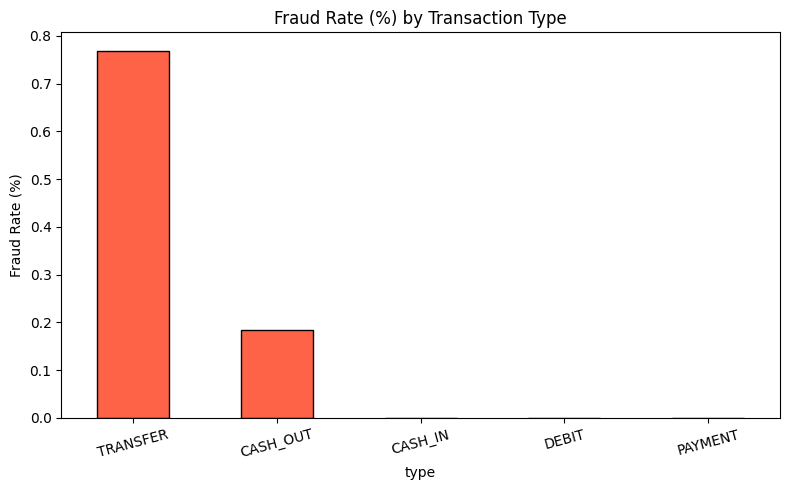

Only TRANSFER and CASH_OUT transactions contain fraud.


In [35]:
# --- Fraud Rate by Transaction Type ---
fraud_by_type = df.groupby('type')['isFraud'].mean() * 100

plt.figure(figsize=(8, 5))
fraud_by_type.sort_values(ascending=False).plot(
    kind='bar', color='tomato', edgecolor='black')
plt.title('Fraud Rate (%) by Transaction Type')
plt.ylabel('Fraud Rate (%)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print('Only TRANSFER and CASH_OUT transactions contain fraud.')

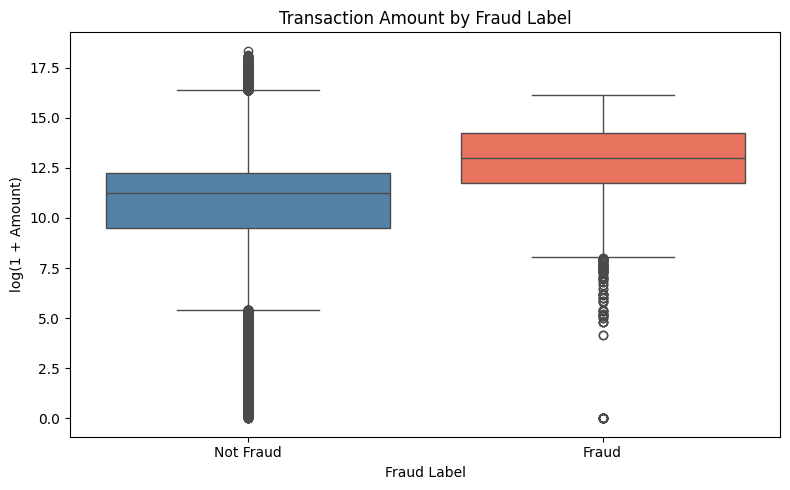

Mean amount — Not Fraud: 178,197
Mean amount — Fraud:     1,467,967
Fraudulent transactions tend to involve much higher amounts.


In [40]:
# --- Transaction Amount vs Fraud ---
df['isFraud_label'] = df['isFraud'].map({0: 'Not Fraud', 1: 'Fraud'})
df['log_amount'] = np.log1p(df['amount'])

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='isFraud_label', y='log_amount',
            hue='isFraud_label',
            palette={'Not Fraud': 'steelblue', 'Fraud': 'tomato'},
            legend=False)
plt.title('Transaction Amount by Fraud Label')
plt.xlabel('Fraud Label')
plt.ylabel('log(1 + Amount)')
plt.tight_layout()
plt.show()

print('Mean amount — Not Fraud: {:,.0f}'.format(df[df['isFraud']==0]['amount'].mean()))
print('Mean amount — Fraud:     {:,.0f}'.format(df[df['isFraud']==1]['amount'].mean()))
print('Fraudulent transactions tend to involve much higher amounts.')

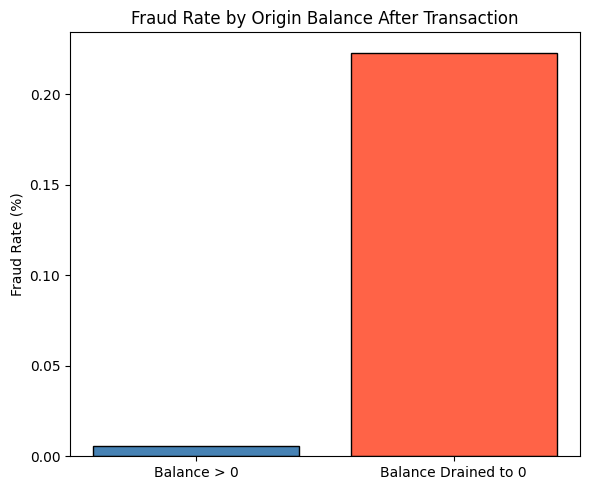

When the origin account is drained to zero, the fraud rate is much higher.


In [37]:
# --- Origin Balance Drained to Zero vs Fraud ---
df['orig_balance_zero'] = (df['newbalanceOrig'] == 0).astype(int)
drain_fraud = df.groupby('orig_balance_zero')['isFraud'].mean() * 100

plt.figure(figsize=(6, 5))
plt.bar(['Balance > 0', 'Balance Drained to 0'],
        drain_fraud.values, color=['steelblue', 'tomato'], edgecolor='black')
plt.title('Fraud Rate by Origin Balance After Transaction')
plt.ylabel('Fraud Rate (%)')
plt.tight_layout()
plt.show()

print('When the origin account is drained to zero, the fraud rate is much higher.')

## 4. Multivariate Analysis

Here I am looking at multiple variables together at the same time 
to see how they interact with each other and with fraud.

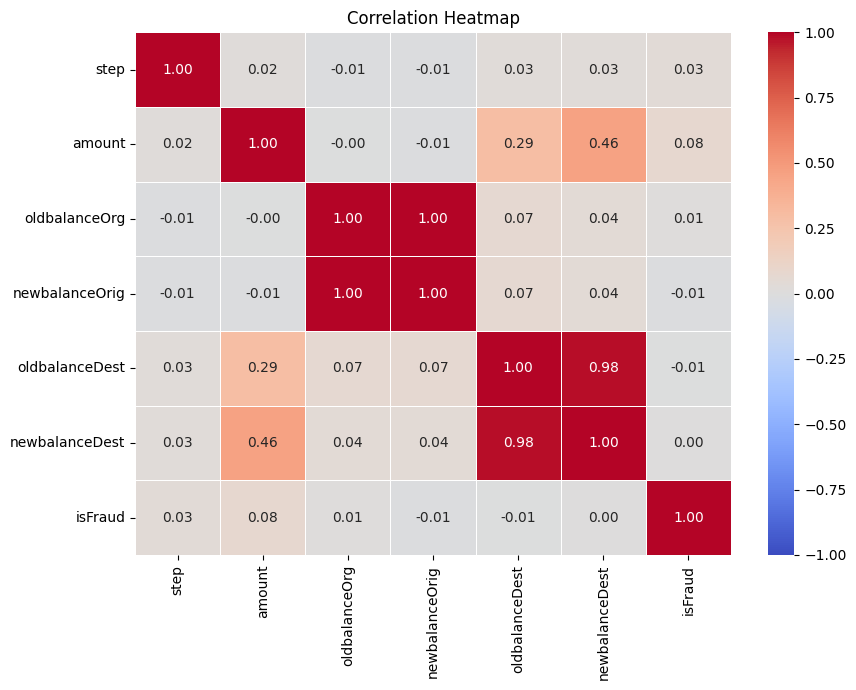

Correlation with isFraud:
amount            0.076688
step              0.031578
oldbalanceOrg     0.010154
newbalanceDest    0.000535
oldbalanceDest   -0.005885
newbalanceOrig   -0.008148
Name: isFraud, dtype: float64


In [38]:
# --- Correlation Heatmap ---
numeric_cols = ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
                'oldbalanceDest', 'newbalanceDest', 'isFraud']

corr = df[numeric_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

print('Correlation with isFraud:')
print(corr['isFraud'].drop('isFraud').sort_values(ascending=False))

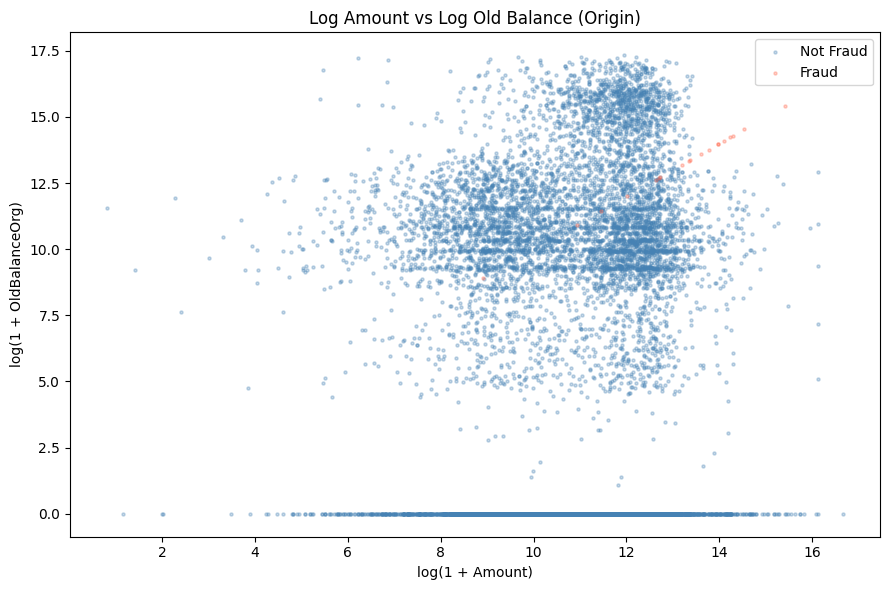

Fraud transactions cluster differently from normal transactions when comparing amount and balance.


In [41]:
# --- Amount vs Old Balance colored by Fraud ---
sample = df.sample(10000, random_state=42)

plt.figure(figsize=(9, 6))
for fraud, color, label in [(0, 'steelblue', 'Not Fraud'), (1, 'tomato', 'Fraud')]:
    sub = sample[sample['isFraud'] == fraud]
    plt.scatter(np.log1p(sub['amount']), np.log1p(sub['oldbalanceOrg']),
                alpha=0.3, color=color, s=5, label=label)

plt.title('Log Amount vs Log Old Balance (Origin)')
plt.xlabel('log(1 + Amount)')
plt.ylabel('log(1 + OldBalanceOrg)')
plt.legend()
plt.tight_layout()
plt.show()
print('Fraud transactions cluster differently from normal transactions when comparing amount and balance.')

## 5. Hypothesis

After looking through the data I noticed a few important things 
that stood out to me:

1. Very few transactions are actually fraud, only about 0.13% of 
the entire dataset which makes it hard for a model to learn from.

2. Fraud only shows up in TRANSFER and CASH_OUT transactions. 
The other transaction types had zero fraud cases.

3. Fraudulent transactions tend to involve a lot more money 
compared to normal transactions.

4. In most fraud cases the origin account gets completely emptied 
out to zero after the transaction.


My Hypothesis:
I believe that fraud can be detected by looking at the transaction 
type, the amount of money being moved, and what happens to the 
account balance after the transaction. Specifically when a large 
amount is transferred or cashed out and the account is left empty, 
that is a strong sign of fraudulent activity.